In [8]:
import sys
import os
sys.path = [p for p in sys.path if "ParaView" not in p]
sys.path.append("/home/haseeb/Notebooks/Parameteric_DMD_cylinder_2D_modules")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['mathtext.fontset'] = 'cm'   # Computer Modern
from flowtorch import DATASETS
from flowtorch.data import FOAMDataloader, mask_box
from sklearn.utils.extmath import randomized_svd
# For High Quality Visuals
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 160  # crisp visuals

In [9]:
alpha_list = np.array([ 3.5, 4.5])

In [ ]:
# Load and prepare data

from Flowtorch_DMD_cylinder_2D_modules.loader_buffet import (
    load_buffet_training_snapshots
)
from Flowtorch_DMD_cylinder_2D_modules.buffet_utils import (
    interpolate_uniform,
    load_force_coeffs
)

# Base folder containing buffet simulations
base_path = os.path.expanduser("~/OpenFOAM/buffet")

# Time window for training
training_window = (0.6, 1.0)

# Sampling step
sampling_step = 1

# Select fields to load
fields = ("Ma", "cl")

# Load training data for all parameters μ ∈ P
train_data, loader0  = load_buffet_training_snapshots(
    param_list=alpha_list,
    base_path=base_path,
    mask_box=mask_box,
    FOAMDataloader=FOAMDataloader,
    training_window=training_window,
    sampling_step=sampling_step,
    fields=fields,
    interpolate_cl=True,
    interpolate_uniform_fn=interpolate_uniform,
    load_force_coeffs_fn=load_force_coeffs
)

# Access training data
X_train_dict   = train_data.snapshots
cl_train_dict  = train_data.cl_train
coords         = train_data.coords
mask_indices   = train_data.mask_indices
num_points     = train_data.num_points
train_times    = train_data.times[alpha_list[0]]
field_info     = train_data.field_info
cell_area      = train_data.cell_area     


[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor1/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor2/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor3/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor4/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor5/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor6/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor7/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor8/constant
[2026-04-07 21:14:44] INFO     Loading precomputed cell centers and volumes from processor9

Loaded training snapshots for α=3.5° (73803, 201)
Loaded training snapshots for α=4.5° (73803, 201)


In [17]:
# Build stacked snapshot matrix

alpha_ref = alpha_list[1]
snapshot_matrix = X_train_dict[alpha_ref]

# Compute SVD
U_s, s_s, Vh_s = randomized_svd(snapshot_matrix, n_components=100)

# Energy and cumulative energy
normalized_energy_s = s_s**2 / np.sum(s_s**2)
cumulative_energy_s = np.cumsum(normalized_energy_s)
residual_content_s = 1 - cumulative_energy_s


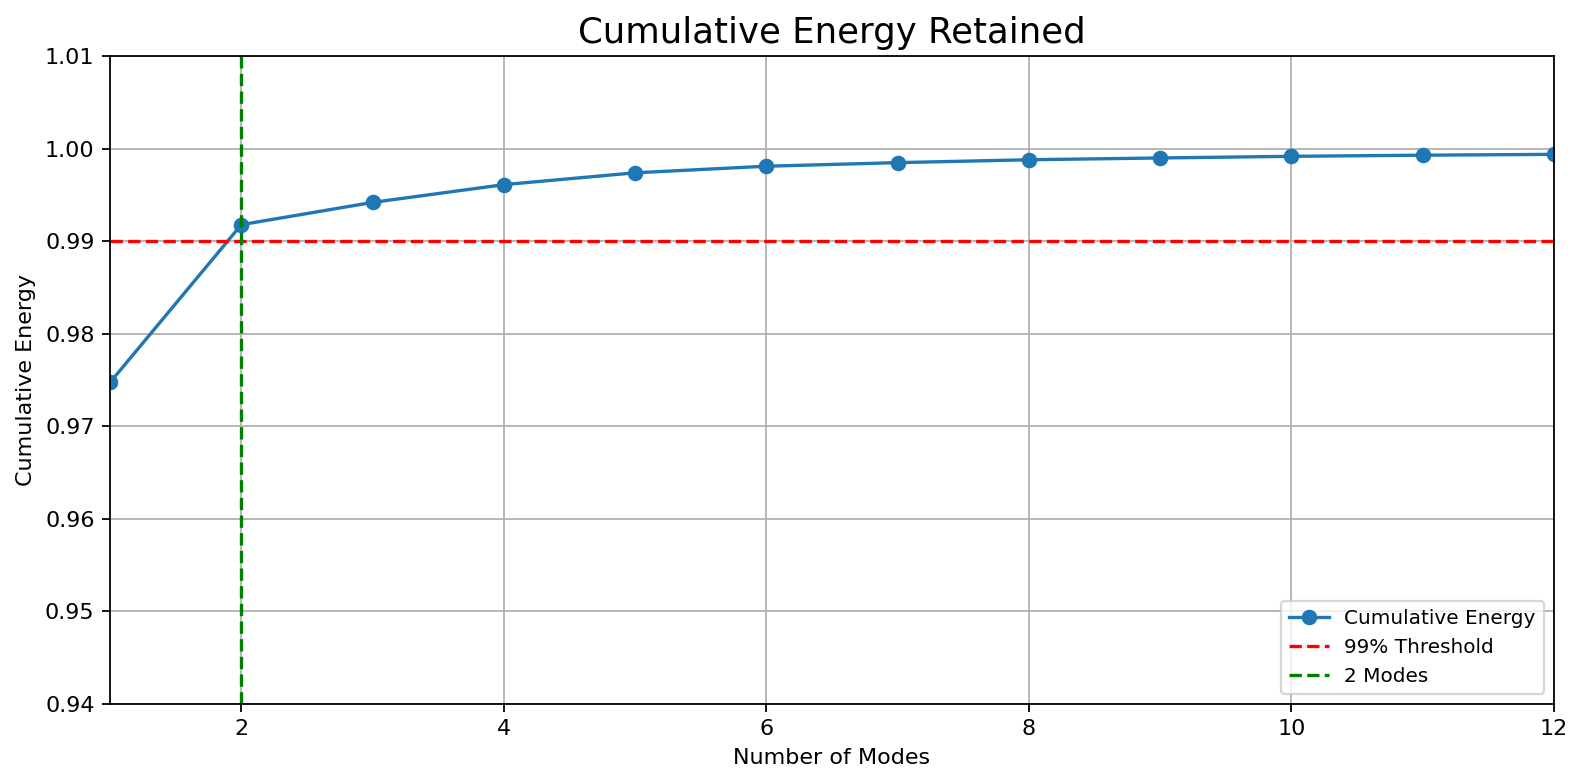

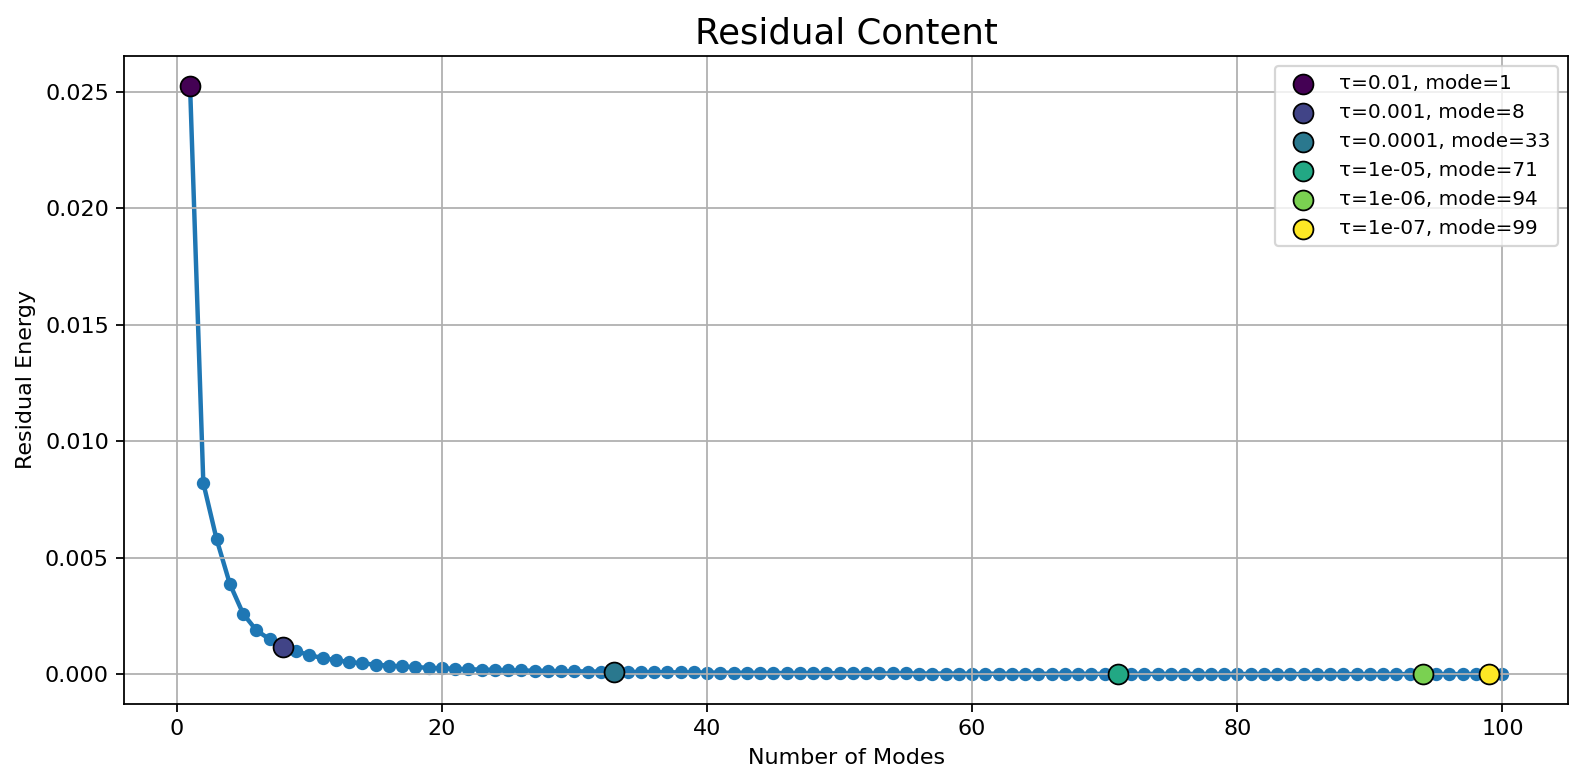

In [19]:
# Thresholds
threshold = 0.99
tau_list = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

num_modes_99_s = np.searchsorted(1 - residual_content_s, threshold) + 1

tau_ranks_s = []
for tau in tau_list:
    idx = np.where(residual_content_s > tau)[0]
    if len(idx) > 0:
        tau_ranks_s.append((tau, idx[-1] + 1))
    else:
        tau_ranks_s.append((tau, None))

# Plot cumulative energy 
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(cumulative_energy_s) + 1),
         cumulative_energy_s, marker='o', label='Cumulative Energy')

plt.axhline(threshold, color='red', linestyle='--', label='99% Threshold')
plt.axvline(num_modes_99_s, color='green', linestyle='--',
            label=f'{num_modes_99_s} Modes')

plt.xlim(max(1, num_modes_99_s - 10),
         min(len(cumulative_energy_s), num_modes_99_s + 10))
plt.ylim(threshold - 0.05, 1.01)

plt.title("Cumulative Energy Retained", fontsize=16)
plt.xlabel("Number of Modes")
plt.ylabel("Cumulative Energy")
plt.grid(True)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Plot residual content

x_vals = np.arange(1, len(residual_content_s) + 1)

plt.figure(figsize=(10, 5))

# 1. Plot the continuous line (no masking)
plt.plot(
    x_vals,
    residual_content_s,
    color='tab:blue',
    linewidth=2,
    marker='o',
    markersize=5,
    zorder=1
)

# 2. Plot tau markers on top (no masking needed)
colors = plt.cm.viridis(np.linspace(0, 1, len(tau_ranks_s)))
for i, (tau, idx) in enumerate(tau_ranks_s):
    if idx is not None:
        y_val = residual_content_s[idx - 1]
        plt.scatter(
            idx, y_val,
            color=colors[i],
            s=80,
            edgecolor='black',
            linewidth=0.8,
            zorder=5,
            label=f"τ={tau}, mode={idx}"
        )

plt.title("Residual Content", fontsize=16)
plt.xlabel("Number of Modes")
plt.ylabel("Residual Energy")
plt.grid(True)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()
